# Project Description

The goal of this proyect is to predict with a high accuracy drawn numbers and serve the model in an API.

> Dataset Information:

> Technologies:

> Metaparameters:

> Final results:

## Import Libraries

In [1]:
import os
# Trick ROCm into treating the RX 6600 like a supported RDNA2 card
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

## Prepare the Dataset

### Transformer to prepare the values from the data

In [3]:
# Data from the dataset (Obtained from the pytorch community)
dataset_mean = 0.1307
dataset_std = 0.3081

# Transformer to turn the images to manipulable data
transform = transforms.Compose([
        transforms.ToTensor(), # Turn pixels to a tensor
        transforms.Normalize( (dataset_mean), (dataset_std) ) # Normalize the data with the mean and standard deviation
])

### Load Train Dataset

In [4]:
train_dataset = datasets.MNIST(
        root='./data/train', # Download location and access path
        train=True, # Set to be the train dataset
        download=False, # It's True if it's the first time to run the code
        transform=transform # Using the transformer above
)

### Load Test Dataset

In [5]:
test_dataset = datasets.MNIST(
        root='./data/test', # Download location and access path
        train=False, # Set to be the test dataset
        download=False, # It's True if it's the first time to run the code
        transform=transform # Using the transformer above
)

### Data Loaders

In [6]:
train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=1028,
        num_workers=4,
        shuffle=True,
        drop_last=True
)

In [7]:
test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=2056, # The double of the train loader is set
        num_workers=4,
        shuffle=True,
        drop_last=False
)

## Data Examples

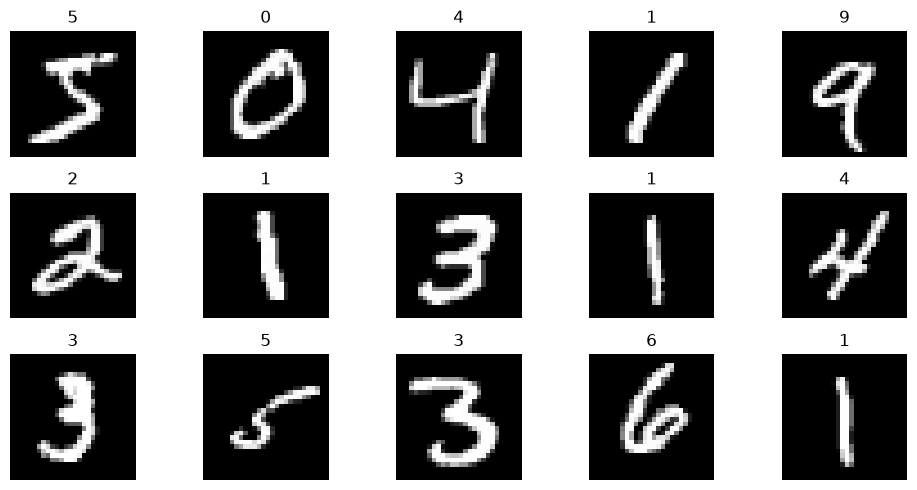

In [8]:
fig, axes = plt.subplots(3,5,figsize=(10,5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    image_np = image.squeeze().numpy()

    ax.imshow(image_np, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Adjust Device

In [9]:
# Looking for the GPU
gpu_exists = torch.cuda.is_available()
print(f"GPU Avaible: {gpu_exists}")

# Printing the GPU name
print(f"GPU: {torch.cuda.get_device_name(0)}" if gpu_exists else "No GPU recognized")

GPU Avaible: True
GPU: AMD Radeon RX 6600


In [10]:
# Setting device as a value to do operations there
device = torch.device("cuda" if gpu_exists else "cpu")
print(f"Using {device}")

Using cuda


## Feed Forward Network Model

In [11]:
class MNISTnet(nn.Module):

    # Initialize Layers
    def __init__(self):
        super().__init__()

        # Input Layer
        self.input = nn.Linear(784, 64) # 784 pixels (28x28)

        # Hidden Layers
        self.fc1 = nn.Linear(64,32)
        self.fc2 = nn.Linear(32,32)

        # Output Layer
        self.output = nn.Linear(32,10)

    # Forward Propagation function
    def forward(self, x):
        x = x.view(x.shape[0], -1)

        x = F.relu( self.input(x) )
        x = F.relu( self.fc1(x) )
        x = F.relu( self.fc2(x) )

        return torch.log_softmax( self.output(x), dim=1 )

## Lossfun & Optimizer

In [12]:
net = MNISTnet()

lossfun = nn.NLLLoss()

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

## Training the Model

In [13]:
# Amount of epochs
numepochs = 100

# Set the model to the device for training
net.to(device)

# Final Metrics to analyze the model
losses = torch.zeros(numepochs)
trainAcc = []
testAcc = []

for epochi in range(numepochs):

    # ===== Train =====
    net.train()

    # Metrics per batch
    batchAcc = []
    batchLoss = []
    
    for X,y in train_loader:
        # Set the values to the device for training
        X,y = X.to(device), y.to(device)

        # Forward Propagation
        yHat = net(X)
        loss = lossfun(yHat, y)

        # Back Propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        batchLoss.append( loss.item() )
    
        matches = torch.argmax( yHat, dim=1 ) == y # Right predictions
        matchesNumeric = matches.float() # Turn boolean to float
        accuracyPct = 100*torch.mean(matchesNumeric) # Percentage
        batchAcc.append( accuracyPct.item() ) # Save

    # Epoch Metrics
    trainAcc.append( np.mean(batchAcc) )
    losses[epochi] = np.mean(batchLoss)

    # ===== Test =====
    net.eval()
    X,y = next(iter(test_loader))

    # Set the values to the device for training
    X,y = X.to(device), y.to(device)

    # Make predictions
    yHat = net(X)

    # Metrics
    acc = 100*torch.mean( (torch.argmax(yHat, dim=1)==y).float() )
    testAcc.append( acc.item() )

    # Print epoch information
    print(f'Epoch: {epochi} \f trainAcc: {trainAcc[epochi]} \f testAcc: {testAcc[epochi]}')

Epoch: 0  trainAcc: 82.4701462285272  testAcc: 93.82295227050781
Epoch: 1  trainAcc: 94.63806573275862  testAcc: 94.94163513183594
Epoch: 2  trainAcc: 96.25654194272798  testAcc: 96.54669189453125
Epoch: 3  trainAcc: 96.88212940610688  testAcc: 97.17899322509766
Epoch: 4  trainAcc: 97.38528218762627  testAcc: 97.47081756591797
Epoch: 5  trainAcc: 97.92197825990874  testAcc: 96.93579864501953
Epoch: 6  trainAcc: 98.10311363483298  testAcc: 97.22763061523438
Epoch: 7  trainAcc: 98.15846068283608  testAcc: 97.13035583496094
Epoch: 8  trainAcc: 98.31276097790948  testAcc: 97.5680923461914
Epoch: 9  trainAcc: 98.47209299021753  testAcc: 97.22763061523438
Epoch: 10  trainAcc: 98.804172910493  testAcc: 97.47081756591797
Epoch: 11  trainAcc: 98.82429991097285  testAcc: 97.22763061523438
Epoch: 12  trainAcc: 98.88970973573882  testAcc: 97.61672973632812
Epoch: 13  trainAcc: 98.97356809418777  testAcc: 97.37354278564453
Epoch: 14  trainAcc: 98.9534412252492  testAcc

## Visualize Loss and Accuracy

[]

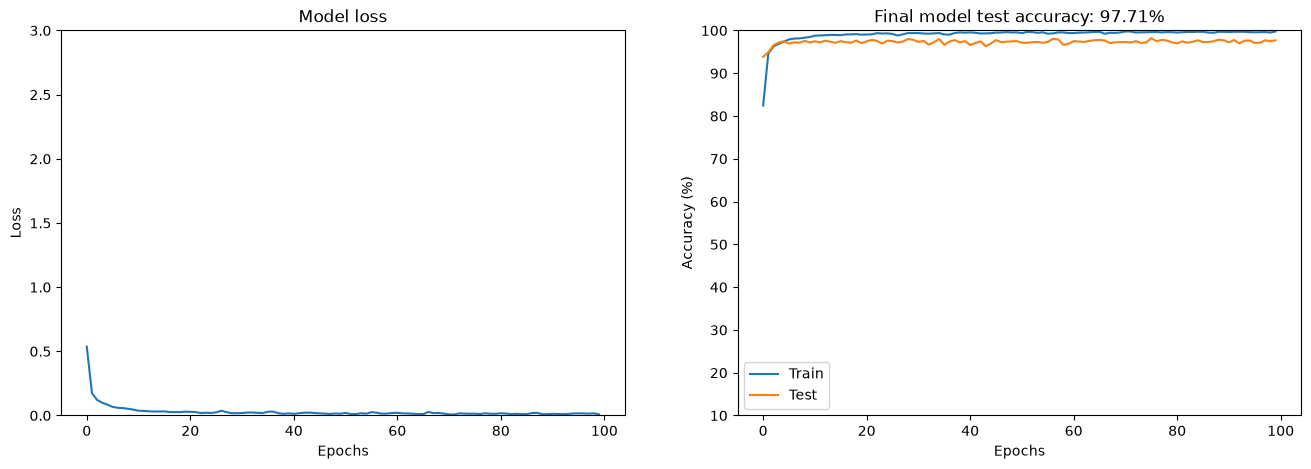

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.plot()

## Visualize Mistakes


Se encontraron 49 errores en este batch.




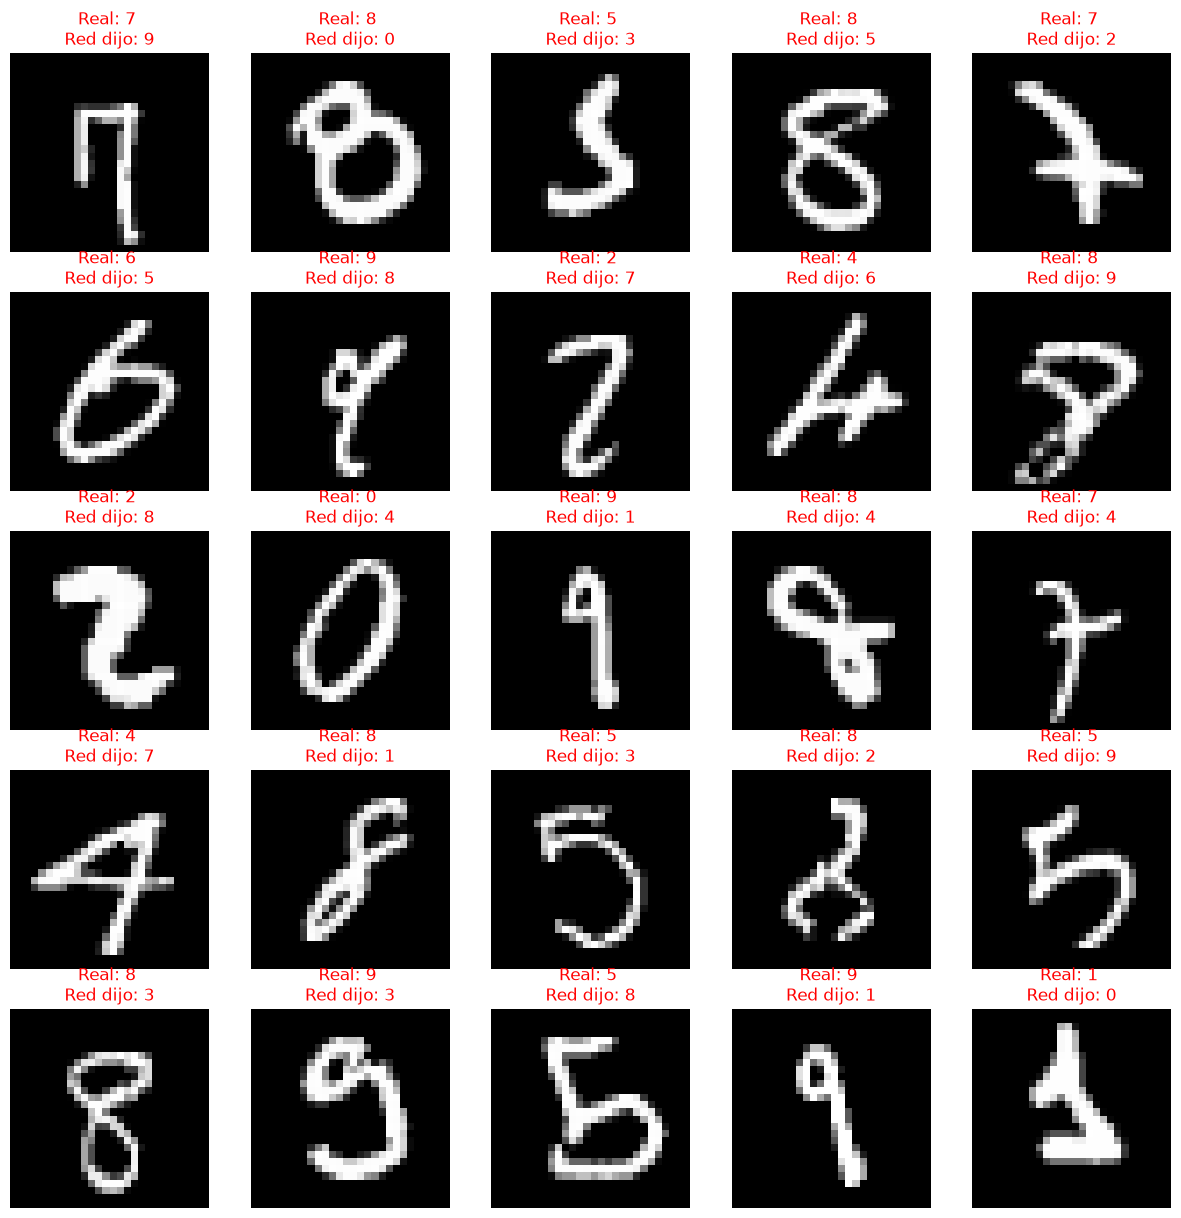

In [19]:
import math
import matplotlib.pyplot as plt
import torch

X, y = next(iter(test_loader))
X, y = X.to(device), y.to(device)

with torch.no_grad():
    predictions = net(X)

predictions = predictions.cpu()
y = y.cpu()
X = X.cpu()

predicted_classes = torch.argmax(predictions, dim=1)
errors = torch.where(predicted_classes != y)[0]

num_errors = len(errors)
print(f'\nSe encontraron {num_errors} errores en este batch.\n\n')

if num_errors > 0:
    max_to_show = min(num_errors, 25) 
    
    cols = 5 
    rows = math.ceil(max_to_show / cols)
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i in range(max_to_show):
        error_idx = errors[i]
        true_val = y[error_idx].item()
        guess_val = predicted_classes[error_idx].item()
        
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_to_show = X[error_idx].view(28, 28)
        ax.imshow(img_to_show, cmap='gray')
        
        ax.set_title(f'Real: {true_val} \nRed dijo: {guess_val}', color='red')
        ax.axis('off') 

## Export Model

In [20]:
net.eval()

torch.save( net.state_dict(), "mnist_mode.pth" )
print("Model exported :)")

Model exported :)
